# Project 03 — Glioblastoma Cellular States (Neftel et al. 2019)

**Author:** Marko Zivanovic, PhD  
**Tool:** Seurat 5 (R)  
**Dataset:** Neftel et al. 2019, *An Integrative Model of Cellular States, Plasticity, and Genetics for Glioblastoma*  
**Accession:** GEO **GSE131928**  
**Reference:** Neftel C, Laffy J, Filbin MG, et al. *Cell* 178, 835-849 (2019). DOI: 10.1016/j.cell.2019.06.024

## Purpose
Reproduce the four canonical glioblastoma cellular states (Mesenchymal MES, Astrocyte-like AC, Oligodendrocyte Progenitor-like OPC, Neural Progenitor-like NPC) defined by Neftel et al. on the Smart-seq2 cohort, then validate on the 10X cohort. Generate the signature 2D state representation ('butterfly plot') alongside standard clustering for direct comparison.

## Pipeline
1. Setup
2. Download GSE131928 (Smart-seq2 + 10X subsets)
3. Load Smart-seq2 cohort
4. QC, normalization (SCTransform v2)
5. Score four canonical states (AddModuleScore)
6. State assignment + butterfly plot (signature reproduction)
7. Standard PCA + UMAP + Louvain clustering
8. Validation on 10X cohort
9. Cross-cohort state distribution
10. Export

## 1. Setup

In [1]:
suppressPackageStartupMessages({
    library(Seurat)
    library(tidyverse)
    library(patchwork)
    library(Matrix)
    library(ggplot2)
})

options(future.globals.maxSize = 8 * 1024^3)  # 8 GB for Seurat parallel ops
set.seed(42)

DATA_DIR    <- '../data'
FIG_DIR     <- '../figures'
RESULTS_DIR <- '../results'
dir.create(DATA_DIR,    recursive = TRUE, showWarnings = FALSE)
dir.create(FIG_DIR,     recursive = TRUE, showWarnings = FALSE)
dir.create(RESULTS_DIR, recursive = TRUE, showWarnings = FALSE)

# Save figures in multiple formats — Seurat-friendly helper
save_fig <- function(plot_obj, name, w = 6, h = 5, dpi = 300, out_dir = FIG_DIR) {
    for (fmt in c('png', 'tiff', 'pdf')) {
        path <- file.path(out_dir, paste0(name, '.', fmt))
        if (fmt == 'tiff') {
            ggsave(path, plot_obj, width = w, height = h, dpi = dpi,
                   device = 'tiff', compression = 'lzw')
        } else {
            ggsave(path, plot_obj, width = w, height = h, dpi = dpi,
                   device = fmt)
        }
        cat('  saved', path, '\n')
    }
}

cat('Seurat:', as.character(packageVersion('Seurat')), '\n')
cat('R:', R.version.string, '\n')

Seurat: 5.3.0 


R: R version 4.3.3 (2024-02-29) 


## 2. Download data

GSE131928 supplementary files include processed expression matrices for both Smart-seq2 (~7k cells, 28 patients) and 10X (~24k cells, 7 patients) cohorts. Both as plain TSV expression tables with gene rows and cell columns.

In [2]:
# URLs for GSE131928 supplementary files (correct GSM-level URLs)
URLS <- list(
    ss2_expr = list(
        url  = 'https://www.ncbi.nlm.nih.gov/geo/download/?acc=GSM3828672&format=file&file=GSM3828672%5FSmartseq2%5FGBM%5FIDHwt%5Fprocessed%5FTPM%2Etsv%2Egz',
        file = 'GSM3828672_Smartseq2_GBM_IDHwt_processed_TPM.tsv.gz'
    ),
    tenx_expr = list(
        url  = 'https://www.ncbi.nlm.nih.gov/geo/download/?acc=GSM3828673&format=file&file=GSM3828673%5F10X%5FGBM%5FIDHwt%5Fprocessed%5FTPM%2Etsv%2Egz',
        file = 'GSM3828673_10X_GBM_IDHwt_processed_TPM.tsv.gz'
    )
)

for (k in names(URLS)) {
    dest <- file.path(DATA_DIR, URLS[[k]]$file)
    if (!file.exists(dest)) {
        cat('Downloading', URLS[[k]]$file, '...\n')
        download.file(URLS[[k]]$url, dest, mode = 'wb', method = 'wget',
                      extra = '-c --tries=3')
    } else {
        cat('Already cached:', URLS[[k]]$file,
            '(', round(file.size(dest) / 1e6, 1), 'MB)\n')
    }
}

Already cached: GSM3828672_Smartseq2_GBM_IDHwt_processed_TPM.tsv.gz ( 310.8 MB)
Already cached: GSM3828673_10X_GBM_IDHwt_processed_TPM.tsv.gz ( 358.3 MB)


## 3. Load Smart-seq2 cohort

In [3]:
ss2_file <- file.path(DATA_DIR, 'GSM3828672_Smartseq2_GBM_IDHwt_processed_TPM.tsv.gz')
cat('Reading Smart-seq2 expression matrix (genes x cells)...\n')
ss2_raw <- read.table(gzfile(ss2_file), header = TRUE, sep = '\t',
                       row.names = 1, check.names = FALSE)
cat('Shape:', nrow(ss2_raw), 'genes x', ncol(ss2_raw), 'cells\n')
cat('First 3 cells:', head(colnames(ss2_raw), 3), '\n')
cat('First 5 genes:', head(rownames(ss2_raw), 5), '\n')

Reading Smart-seq2 expression matrix (genes x cells)...


Shape: 23686 genes x 7930 cells


First 3 cells: MGH101-P1-A04 MGH101-P1-A05 MGH101-P1-A07 


First 5 genes: A1BG A1BG-AS1 A1CF A2M A2M-AS1 


In [4]:
# Convert to sparse matrix to save memory
ss2_mat <- Matrix::Matrix(as.matrix(ss2_raw), sparse = TRUE)
rm(ss2_raw); gc()

# Extract patient ID from cell name (format usually like 'MGH101_P1_xxx')
patient_id <- sapply(strsplit(colnames(ss2_mat), '[-_]'), `[`, 1)

# Build Seurat object
ss2 <- CreateSeuratObject(counts = ss2_mat, project = 'Neftel_SS2',
                          min.cells = 3, min.features = 200)
ss2$patient <- patient_id[match(colnames(ss2), colnames(ss2_mat))]
ss2$cohort  <- 'Smart-seq2'

cat('Smart-seq2 Seurat object:\n')
print(ss2)
cat('\nPatients:\n')
print(table(ss2$patient))

,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,3491407,186.5,7072502,377.8,5355598,286.1
Vcells,74790290,570.7,368649146,2812.6,450560447,3437.6


Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”


Smart-seq2 Seurat object:


An object of class Seurat 
22197 features across 7930 samples within 1 assay 
Active assay: RNA (22197 features, 0 variable features)
 1 layer present: counts



Patients:



        BT1160         BT1187          BT749          BT771          BT786 
           335            219            317            339            212 
         BT830          BT920         MGH100         MGH101         MGH102 
           220            301            209            200            312 
        MGH104    MGH104negP2    MGH104negP4    MGH104negP7        MGH105A 
           139             65             74             77            160 
       MGH105B        MGH105C        MGH105D         MGH106 MGH106CD3posP1 
           122            167            185            135             65 
        MGH110         MGH113         MGH115         MGH121         MGH122 
           359            260            165            297            273 
        MGH124         MGH125  MGH128CD45neg  MGH129CD45neg  MGH136CD45neg 
           370            399            184            192            231 
 MGH143CD45neg  MGH151CD45neg  MGH152CD45neg          MGH66          MGH85 
           

## 4. QC and normalization (Smart-seq2)

QC stats before filtering:


  nFeature_RNA     nCount_RNA      percent.mt
 Min.   : 3003   Min.   : 4977   Min.   :0   
 1st Qu.: 4639   1st Qu.:12587   1st Qu.:0   
 Median : 5660   Median :14759   Median :0   
 Mean   : 5735   Mean   :14519   Mean   :0   
 3rd Qu.: 6752   3rd Qu.:16587   3rd Qu.:0   
 Max.   :11890   Max.   :24184   Max.   :0   


Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”


Warning message:
“The `slot` argument of `FetchData()` is deprecated as of SeuratObject 5.0.0.
ℹ Please use the `layer` argument instead.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”


Warning message:
“`PackageCheck()` was deprecated in SeuratObject 5.0.0.
ℹ Please use `rlang::check_installed()` instead.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”


Warning message in SingleExIPlot(type = type, data = data[, x, drop = FALSE], idents = idents, :
“All cells have the same value of percent.mt.”


  saved ../figures/01_qc_violins_ss2.png 


  saved ../figures/01_qc_violins_ss2.tiff 


  saved ../figures/01_qc_violins_ss2.pdf 


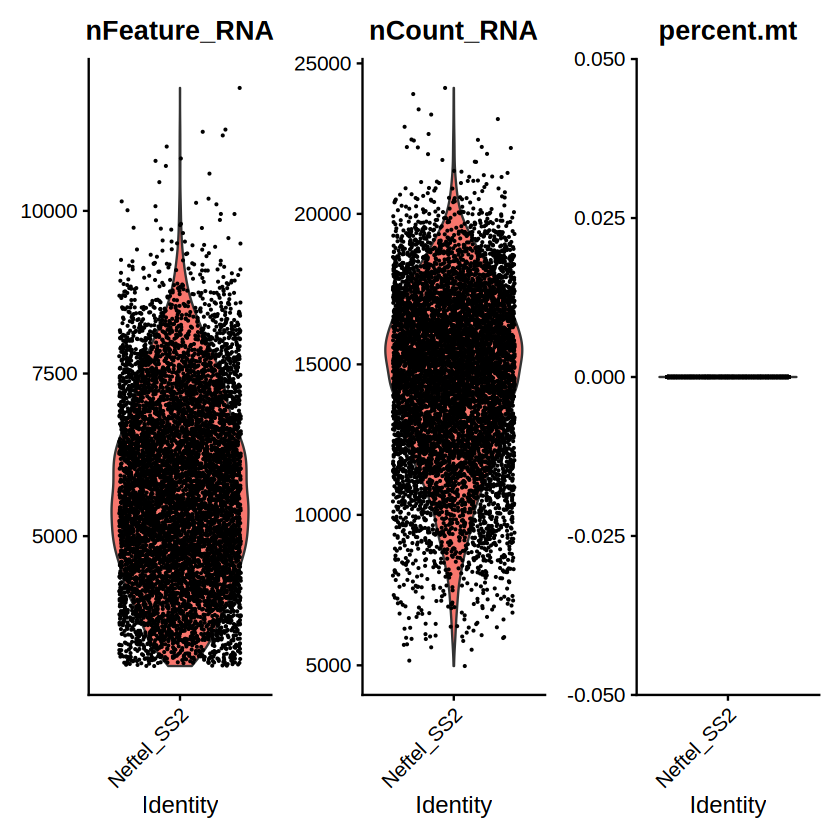

In [5]:
# QC: percent mitochondrial
ss2[['percent.mt']] <- PercentageFeatureSet(ss2, pattern = '^MT-')

# Smart-seq2 has higher gene counts than 10X — different thresholds apply
cat('QC stats before filtering:\n')
print(summary(ss2[[c('nFeature_RNA', 'nCount_RNA', 'percent.mt')]]))

# QC violins
p <- VlnPlot(ss2, features = c('nFeature_RNA', 'nCount_RNA', 'percent.mt'),
             ncol = 3, pt.size = 0.1) & theme(legend.position = 'none')
save_fig(p, '01_qc_violins_ss2', w = 12, h = 4)
print(p)

In [6]:
# Filter — modest thresholds (Smart-seq2 is deeper than 10X)
n_before <- ncol(ss2)
ss2 <- subset(ss2, subset = nFeature_RNA > 1000 &
                              nFeature_RNA < 10000 &
                              percent.mt < 20)
cat('Cells:', n_before, '->', ncol(ss2), '\n')

# Standard log-normalization (state scoring on Smart-seq2 in Neftel uses log-transformed TPM/counts)
ss2 <- NormalizeData(ss2, normalization.method = 'LogNormalize',
                     scale.factor = 10000, verbose = FALSE)
ss2 <- FindVariableFeatures(ss2, selection.method = 'vst', nfeatures = 3000,
                             verbose = FALSE)
ss2 <- ScaleData(ss2, verbose = FALSE)
cat('Normalization done.\n')

Cells: 7930 -> 7914 


Normalization done.


## 5. Score the four glioblastoma states

Neftel et al. defined six gene signatures that collapse into four states:
- **MES**: MES1 + MES2 (mesenchymal)
- **AC**: AC (astrocyte-like)
- **OPC**: OPC (oligodendrocyte progenitor-like)
- **NPC**: NPC1 + NPC2 (neural progenitor-like)

Gene lists are taken from Neftel 2019 Table S2.

In [7]:
# Six gene signatures from Neftel 2019 Table S2
neftel_sigs <- list(
    MES1 = c('CHI3L1','ANXA2','ANXA1','CD44','VIM','MT2A','C1S','NAMPT','EFEMP1',
             'C1R','SOD2','IFITM3','TIMP1','SPP1','A2M','S100A11','MT1X','S100A10',
             'FN1','LGALS1','CD63','LY96','GFPT2','TGFBI','ANGPTL4'),
    MES2 = c('HILPDA','ADM','DDIT3','NDRG1','HERPUD1','DNAJB9','TRIB3','ENO2',
             'AKAP12','SQSTM1','MT1X','ATF3','NUPR1','SLC2A3','BNIP3','LGALS3',
             'INSIG2','PLOD2','UBC','VEGFA','HSPA5','ERO1A','EGLN3','CA9','PGK1'),
    AC   = c('CST3','S100B','SLC1A3','HEPN1','HOPX','MT3','SPARCL1','MLC1','GFAP',
             'FABP7','BCAN','PON2','METRN','SPARC','GATM','RAMP1','PMP2','AQP4',
             'DBI','EDNRB','PTPRZ1','CLU','PMP22','ATP1A2','S100A16'),
    OPC  = c('BCAN','PLP1','GPR17','FIBIN','LHFPL3','OLIG1','PSAT1','SCRG1','OMG',
             'APOD','SIRT2','TNR','THY1','PHYHIPL','SOX2-OT','NKAIN4','LPPR1',
             'PTPRZ1','VCAN','DBI','PMP2','CNP','TNS3','LIMA1'),
    NPC1 = c('DLL3','DLL1','SOX4','TUBB3','HES6','TAGLN3','NEU4','MARCKSL1','CD24',
             'STMN1','TCF4','TCF12','NREP','BEX1','HMP19','SOX11','MLLT11','NPPA',
             'TUBA1A','RND3','MIAT','TNR','SNAP25','RTN1','RTKN'),
    NPC2 = c('STMN2','STMN1','STMN4','TUBB3','MIAT','DCX','NSG1','ELAVL4','MLLT11',
             'DLX5','DLX6-AS1','SOX11','NREP','TUBA1A','TAGLN3','DLX1','DLX2',
             'BLCAP','HN1','NFIB','TUBB2A','NDN','CD24','RND3','CRABP1')
)

cat('Signature sizes:\n')
for (s in names(neftel_sigs)) {
    present <- sum(neftel_sigs[[s]] %in% rownames(ss2))
    cat('  ', s, ':', present, '/', length(neftel_sigs[[s]]), 'genes present\n')
}

Signature sizes:


   MES1 : 25 / 25 genes present
   MES2 : 24 / 25 genes present
   AC : 25 / 25 genes present
   OPC : 24 / 24 genes present
   NPC1 : 25 / 25 genes present
   NPC2 : 25 / 25 genes present


In [8]:
# Score each signature using Seurat AddModuleScore
for (s in names(neftel_sigs)) {
    genes_present <- neftel_sigs[[s]][neftel_sigs[[s]] %in% rownames(ss2)]
    ss2 <- AddModuleScore(ss2, features = list(genes_present),
                          name = paste0(s, '_score'), seed = 42)
}

# Seurat adds suffix '1' to module scores — rename for clarity
for (s in names(neftel_sigs)) {
    old <- paste0(s, '_score1')
    if (old %in% colnames(ss2[[]])) {
        ss2[[s]] <- ss2[[old]]
        ss2[[old]] <- NULL
    }
}

# Collapse 6 signatures into 4 states (Neftel: state = max of paired sub-signatures)
ss2$MES_score <- pmax(ss2$MES1, ss2$MES2)
ss2$AC_score  <- ss2$AC
ss2$OPC_score <- ss2$OPC
ss2$NPC_score <- pmax(ss2$NPC1, ss2$NPC2)

cat('State scores computed. Summary:\n')
print(summary(ss2[[c('MES_score', 'AC_score', 'OPC_score', 'NPC_score')]]))

Warning message:
“The `slot` argument of `GetAssayData()` is deprecated as of SeuratObject 5.0.0.
ℹ Please use the `layer` argument instead.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”


State scores computed. Summary:


   MES_score           AC_score           OPC_score          NPC_score       
 Min.   :-0.37458   Min.   :-0.769552   Min.   :-0.63238   Min.   :-0.47948  
 1st Qu.:-0.05299   1st Qu.:-0.272063   1st Qu.:-0.22065   1st Qu.:-0.13255  
 Median : 0.08118   Median :-0.001616   Median : 0.02923   Median : 0.08207  
 Mean   : 0.15132   Mean   : 0.046271   Mean   : 0.02626   Mean   : 0.11144  
 3rd Qu.: 0.28809   3rd Qu.: 0.371327   3rd Qu.: 0.25433   3rd Qu.: 0.30515  
 Max.   : 1.43332   Max.   : 1.412676   Max.   : 0.99465   Max.   : 1.32107  


## 6. State assignment and butterfly plot

**Neftel 2D state representation:**
- Y-axis: SCopc/npc - SCmes/ac (developmental vs injury response axis)
- X-axis (only for upper or lower half separately): log2(|SCnpc - SCopc| + 1) signed by which is larger; same logic for MES/AC below

This produces the canonical 'butterfly' layout: NPC top-left, OPC top-right, AC bottom-left, MES bottom-right.

In [9]:
# Compute Neftel 2D coordinates per cell
df <- ss2[[c('MES_score', 'AC_score', 'OPC_score', 'NPC_score', 'patient')]]

SC_opc_npc <- pmax(df$OPC_score, df$NPC_score)
SC_mes_ac  <- pmax(df$MES_score, df$AC_score)
df$y <- SC_opc_npc - SC_mes_ac

# X-axis: in top half use NPC vs OPC, in bottom half use MES vs AC
df$x <- ifelse(
    df$y > 0,
    log2(abs(df$NPC_score - df$OPC_score) + 1) * sign(df$NPC_score - df$OPC_score),
    log2(abs(df$MES_score - df$AC_score)   + 1) * sign(df$MES_score - df$AC_score)
)

# Assign dominant state per cell
state_scores <- df[, c('MES_score','AC_score','OPC_score','NPC_score')]
state_names  <- c('MES','AC','OPC','NPC')
df$state <- factor(state_names[apply(state_scores, 1, which.max)],
                   levels = c('NPC','OPC','AC','MES'))

ss2$state <- df$state
ss2$bp_x  <- df$x
ss2$bp_y  <- df$y

cat('State distribution (Smart-seq2):\n')
print(table(ss2$state))

State distribution (Smart-seq2):



 NPC  OPC   AC  MES 
1888 1708 2200 2118 


  saved ../figures/hero_butterfly_plot.png 


  saved ../figures/hero_butterfly_plot.tiff 


Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Glioblastoma cellular states — Neftel 2D representation' in 'mbcsToSbcs': dot substituted for <e2>”


Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Glioblastoma cellular states — Neftel 2D representation' in 'mbcsToSbcs': dot substituted for <80>”


Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Glioblastoma cellular states — Neftel 2D representation' in 'mbcsToSbcs': dot substituted for <94>”


...

Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Glioblastoma cellular states — Neftel 2D representation' in 'mbcsToSbcs': dot substituted for <94>”


Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Glioblastoma cellular states — Neftel 2D representation' in 'mbcsToSbcs': dot substituted for <e2>”


Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Glioblastoma cellular states — Neftel 2D representation' in 'mbcsToSbcs': dot substituted for <80>”


Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Glioblastoma cellular states — Neftel 2D representation' in 'mbcsToSbcs': dot substituted for <94>”


  saved ../figures/hero_butterfly_plot.pdf 


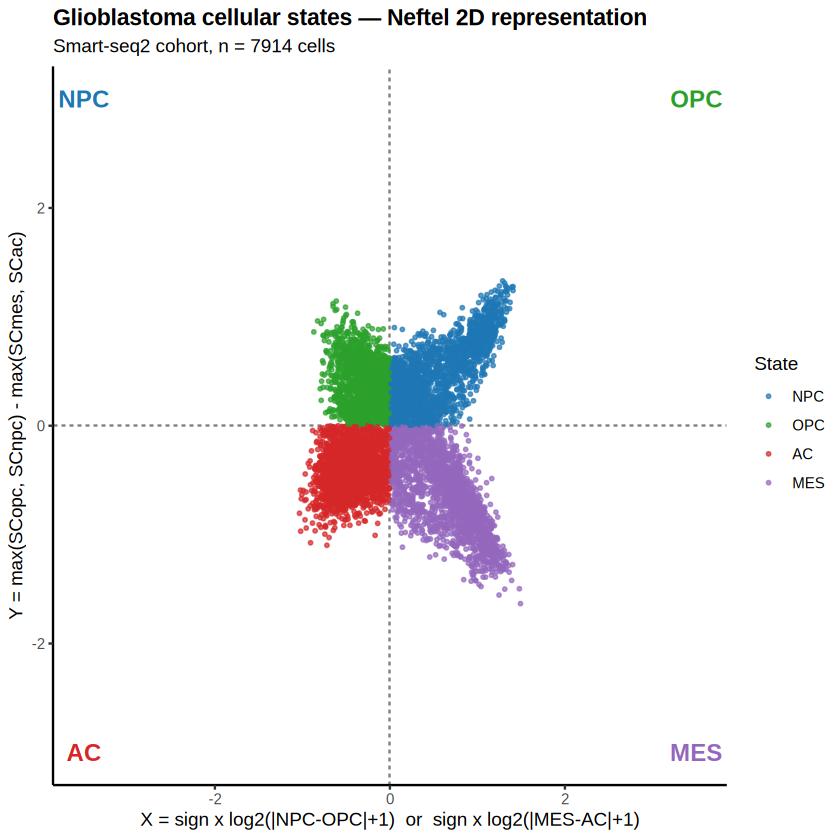

In [10]:
# Butterfly plot — signature Neftel 2019 figure
state_colors <- c('NPC' = '#1f77b4', 'OPC' = '#2ca02c',
                  'AC'  = '#d62728', 'MES' = '#9467bd')

p_bp <- ggplot(df, aes(x = x, y = y, color = state)) +
    geom_hline(yintercept = 0, color = 'grey50', linetype = 'dashed') +
    geom_vline(xintercept = 0, color = 'grey50', linetype = 'dashed') +
    geom_point(size = 0.6, alpha = 0.7) +
    scale_color_manual(values = state_colors, name = 'State') +
    labs(
        title = 'Glioblastoma cellular states — Neftel 2D representation',
        subtitle = paste0('Smart-seq2 cohort, n = ', ncol(ss2), ' cells'),
        x = 'X = sign x log2(|NPC-OPC|+1)  or  sign x log2(|MES-AC|+1)',
        y = 'Y = max(SCopc, SCnpc) - max(SCmes, SCac)'
    ) +
    annotate('text', x = -3.5, y =  3.0, label = 'NPC', size = 5, fontface = 'bold', color = state_colors['NPC']) +
    annotate('text', x =  3.5, y =  3.0, label = 'OPC', size = 5, fontface = 'bold', color = state_colors['OPC']) +
    annotate('text', x = -3.5, y = -3.0, label = 'AC',  size = 5, fontface = 'bold', color = state_colors['AC']) +
    annotate('text', x =  3.5, y = -3.0, label = 'MES', size = 5, fontface = 'bold', color = state_colors['MES']) +
    theme_classic(base_size = 11) +
    theme(legend.position = 'right',
          plot.title = element_text(face = 'bold'))

save_fig(p_bp, 'hero_butterfly_plot', w = 8, h = 7)
print(p_bp)

## 7. Standard PCA + UMAP + Louvain clustering (for comparison)

Warning message:
“The default method for RunUMAP has changed from calling Python UMAP via reticulate to the R-native UWOT using the cosine metric
To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session”


Louvain clusters: 23 


  saved ../figures/02_umap_state_cluster_patient.png 


  saved ../figures/02_umap_state_cluster_patient.tiff 


Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'UMAP — colored by assigned state' in 'mbcsToSbcs': dot substituted for <e2>”


...

Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'UMAP — colored by patient' in 'mbcsToSbcs': dot substituted for <94>”


Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'UMAP — colored by patient' in 'mbcsToSbcs': dot substituted for <e2>”


Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'UMAP — colored by patient' in 'mbcsToSbcs': dot substituted for <80>”


Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'UMAP — colored by patient' in 'mbcsToSbcs': dot substituted for <94>”


  saved ../figures/02_umap_state_cluster_patient.pdf 


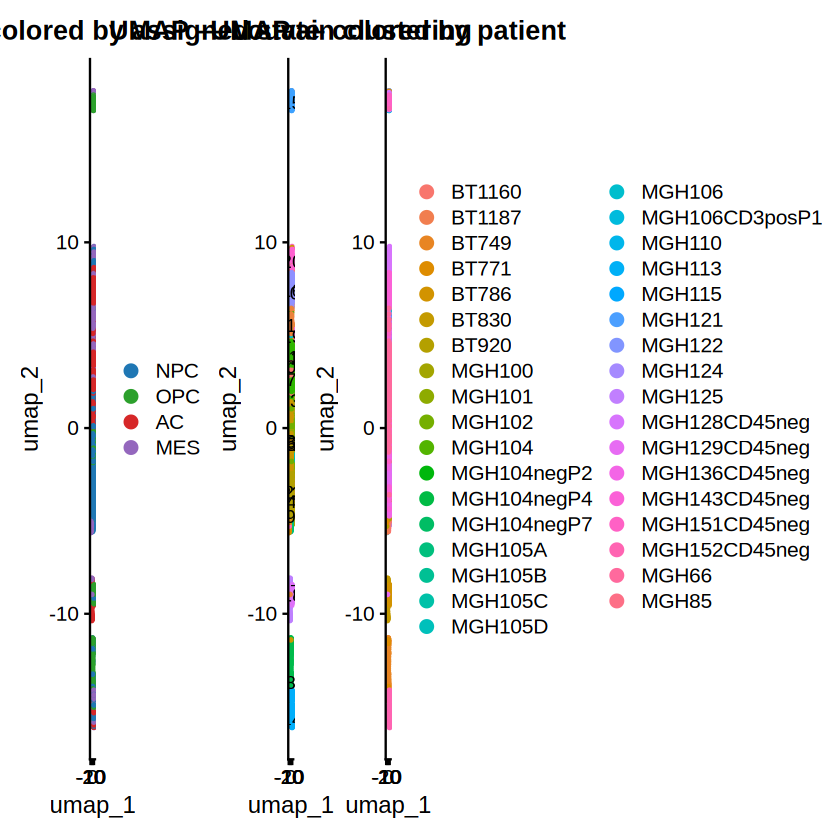

In [11]:
ss2 <- RunPCA(ss2, npcs = 50, verbose = FALSE, seed.use = 42)
ss2 <- RunUMAP(ss2, dims = 1:30, verbose = FALSE, seed.use = 42)
ss2 <- FindNeighbors(ss2, dims = 1:30, verbose = FALSE)
ss2 <- FindClusters(ss2, resolution = 0.5, verbose = FALSE, random.seed = 42)

cat('Louvain clusters:', length(unique(ss2$seurat_clusters)), '\n')

# UMAP colored by state and by cluster, side by side
p1 <- DimPlot(ss2, reduction = 'umap', group.by = 'state',
              cols = state_colors, pt.size = 0.4) +
      ggtitle('UMAP — colored by assigned state')
p2 <- DimPlot(ss2, reduction = 'umap', group.by = 'seurat_clusters',
              pt.size = 0.4, label = TRUE) +
      ggtitle('UMAP — Louvain clustering') + NoLegend()
p3 <- DimPlot(ss2, reduction = 'umap', group.by = 'patient', pt.size = 0.4) +
      ggtitle('UMAP — colored by patient')

p_umap <- (p1 | p2 | p3)
save_fig(p_umap, '02_umap_state_cluster_patient', w = 16, h = 5)
print(p_umap)

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


  saved ../figures/03_state_scores_umap.png 


  saved ../figures/03_state_scores_umap.tiff 


  saved ../figures/03_state_scores_umap.pdf 


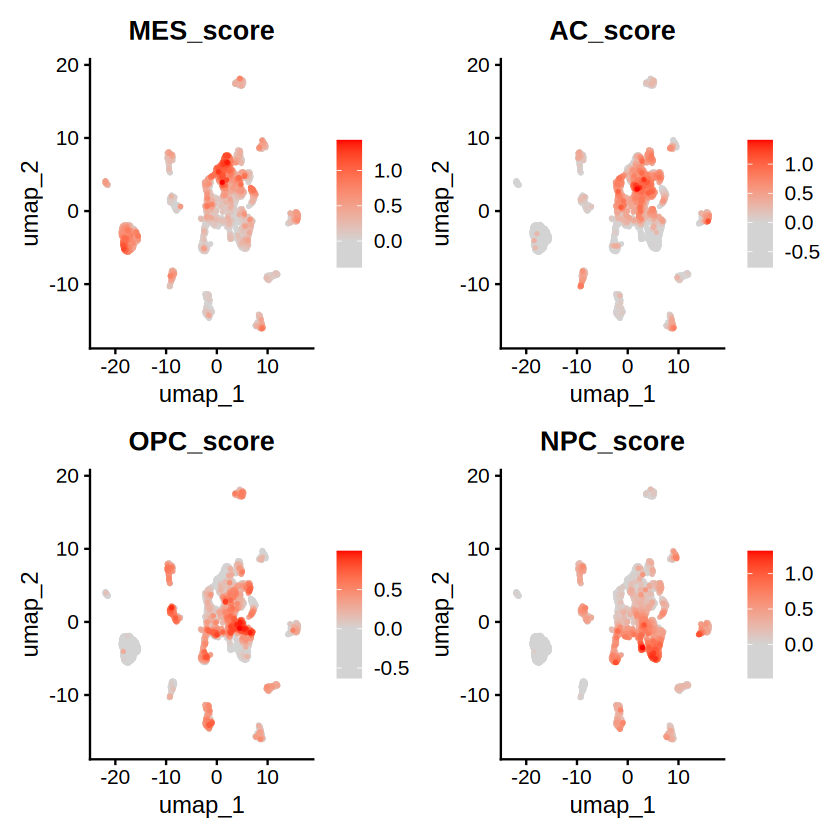

In [12]:
# State score heatmaps on UMAP — shows continuous gradient
p_scores <- FeaturePlot(
    ss2, features = c('MES_score', 'AC_score', 'OPC_score', 'NPC_score'),
    pt.size = 0.3, ncol = 2, order = TRUE
) & scale_color_gradient2(low = 'lightgrey', mid = 'lightgrey',
                            high = 'red', midpoint = 0)
save_fig(p_scores, '03_state_scores_umap', w = 11, h = 9)
print(p_scores)

## 8. Validate on 10X cohort

In [13]:
tenx_file <- file.path(DATA_DIR, 'GSM3828673_10X_GBM_IDHwt_processed_TPM.tsv.gz')
cat('Reading 10X expression matrix...\n')
tenx_raw <- read.table(gzfile(tenx_file), header = TRUE, sep = '\t',
                        row.names = 1, check.names = FALSE)
cat('Shape:', nrow(tenx_raw), 'genes x', ncol(tenx_raw), 'cells\n')

tenx_mat <- Matrix::Matrix(as.matrix(tenx_raw), sparse = TRUE)
rm(tenx_raw); gc()

patient_id_10x <- sapply(strsplit(colnames(tenx_mat), '[-_]'), `[`, 1)

tenx <- CreateSeuratObject(counts = tenx_mat, project = 'Neftel_10X',
                           min.cells = 3, min.features = 200)
tenx$patient <- patient_id_10x[match(colnames(tenx), colnames(tenx_mat))]
tenx$cohort  <- '10X'
tenx[['percent.mt']] <- PercentageFeatureSet(tenx, pattern = '^MT-')

# 10X has lower per-cell coverage than Smart-seq2 — gentler thresholds
n_before_10x <- ncol(tenx)
tenx <- subset(tenx, subset = nFeature_RNA > 500 &
                                nFeature_RNA < 8000 &
                                percent.mt < 25)
cat('10X cells:', n_before_10x, '->', ncol(tenx), '\n')

tenx <- NormalizeData(tenx, verbose = FALSE)
tenx <- FindVariableFeatures(tenx, nfeatures = 3000, verbose = FALSE)
tenx <- ScaleData(tenx, verbose = FALSE)

Reading 10X expression matrix...


Shape: 30314 genes x 16201 cells


,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,3950599,211.0,7072502,377.8,7072502,377.8
Vcells,359353010,2741.7,1269155018,9682.9,1341760952,10236.9


Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”


10X cells: 15112 -> 13518 


In [14]:
# Score same signatures on 10X data
for (s in names(neftel_sigs)) {
    genes_present <- neftel_sigs[[s]][neftel_sigs[[s]] %in% rownames(tenx)]
    tenx <- AddModuleScore(tenx, features = list(genes_present),
                           name = paste0(s, '_score'), seed = 42)
}
for (s in names(neftel_sigs)) {
    old <- paste0(s, '_score1')
    if (old %in% colnames(tenx[[]])) {
        tenx[[s]] <- tenx[[old]]
        tenx[[old]] <- NULL
    }
}
tenx$MES_score <- pmax(tenx$MES1, tenx$MES2)
tenx$AC_score  <- tenx$AC
tenx$OPC_score <- tenx$OPC
tenx$NPC_score <- pmax(tenx$NPC1, tenx$NPC2)

# Butterfly coordinates on 10X
df_10x <- tenx[[c('MES_score','AC_score','OPC_score','NPC_score','patient')]]
SC_opc_npc <- pmax(df_10x$OPC_score, df_10x$NPC_score)
SC_mes_ac  <- pmax(df_10x$MES_score, df_10x$AC_score)
df_10x$y <- SC_opc_npc - SC_mes_ac
df_10x$x <- ifelse(
    df_10x$y > 0,
    log2(abs(df_10x$NPC_score - df_10x$OPC_score) + 1) * sign(df_10x$NPC_score - df_10x$OPC_score),
    log2(abs(df_10x$MES_score - df_10x$AC_score) + 1) * sign(df_10x$MES_score - df_10x$AC_score)
)
state_scores_10x <- df_10x[, c('MES_score','AC_score','OPC_score','NPC_score')]
df_10x$state <- factor(state_names[apply(state_scores_10x, 1, which.max)],
                       levels = c('NPC','OPC','AC','MES'))
tenx$state <- df_10x$state
tenx$bp_x  <- df_10x$x
tenx$bp_y  <- df_10x$y

cat('State distribution (10X):\n')
print(table(tenx$state))

State distribution (10X):



 NPC  OPC   AC  MES 
2429  872 2701 7516 


  saved ../figures/04_butterfly_ss2_vs_10x.png 


  saved ../figures/04_butterfly_ss2_vs_10x.tiff 


  saved ../figures/04_butterfly_ss2_vs_10x.pdf 


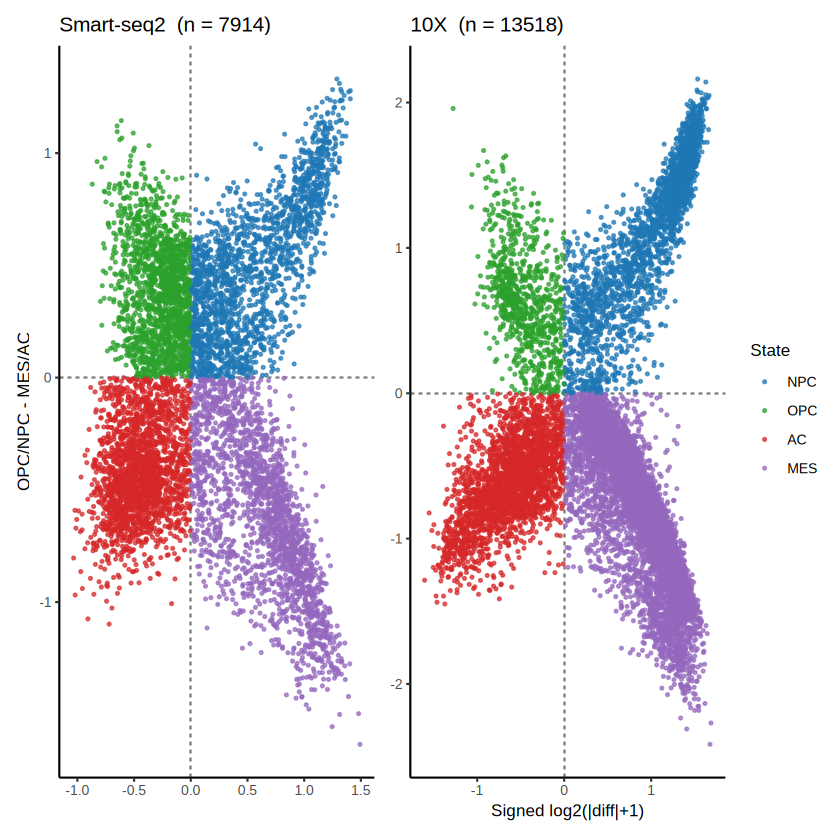

In [15]:
# Side-by-side butterfly plot: SS2 vs 10X
p_bp_ss2 <- ggplot(df, aes(x = x, y = y, color = state)) +
    geom_hline(yintercept = 0, color = 'grey50', linetype = 'dashed') +
    geom_vline(xintercept = 0, color = 'grey50', linetype = 'dashed') +
    geom_point(size = 0.4, alpha = 0.7) +
    scale_color_manual(values = state_colors, name = 'State') +
    labs(title = paste0('Smart-seq2  (n = ', ncol(ss2), ')'),
         x = NULL, y = 'OPC/NPC - MES/AC') +
    theme_classic(base_size = 10) + theme(legend.position = 'none')

p_bp_10x <- ggplot(df_10x, aes(x = x, y = y, color = state)) +
    geom_hline(yintercept = 0, color = 'grey50', linetype = 'dashed') +
    geom_vline(xintercept = 0, color = 'grey50', linetype = 'dashed') +
    geom_point(size = 0.4, alpha = 0.7) +
    scale_color_manual(values = state_colors, name = 'State') +
    labs(title = paste0('10X  (n = ', ncol(tenx), ')'),
         x = 'Signed log2(|diff|+1)', y = NULL) +
    theme_classic(base_size = 10)

p_compare <- p_bp_ss2 | p_bp_10x
save_fig(p_compare, '04_butterfly_ss2_vs_10x', w = 13, h = 6)
print(p_compare)

## 9. Cross-cohort state distribution

State composition by cohort:


# A tibble: 8 × 4
# Groups:   cohort [2]
  cohort     state     n   pct
  <chr>      <fct> <int> <dbl>
1 10X        NPC    2429 18.0 
2 10X        OPC     872  6.45
3 10X        AC     2701 20.0 
4 10X        MES    7516 55.6 
5 Smart-seq2 NPC    1888 23.9 
6 Smart-seq2 OPC    1708 21.6 
7 Smart-seq2 AC     2200 27.8 
8 Smart-seq2 MES    2118 26.8 


  saved ../figures/05_state_composition_cohorts.png 


  saved ../figures/05_state_composition_cohorts.tiff 


  saved ../figures/05_state_composition_cohorts.pdf 


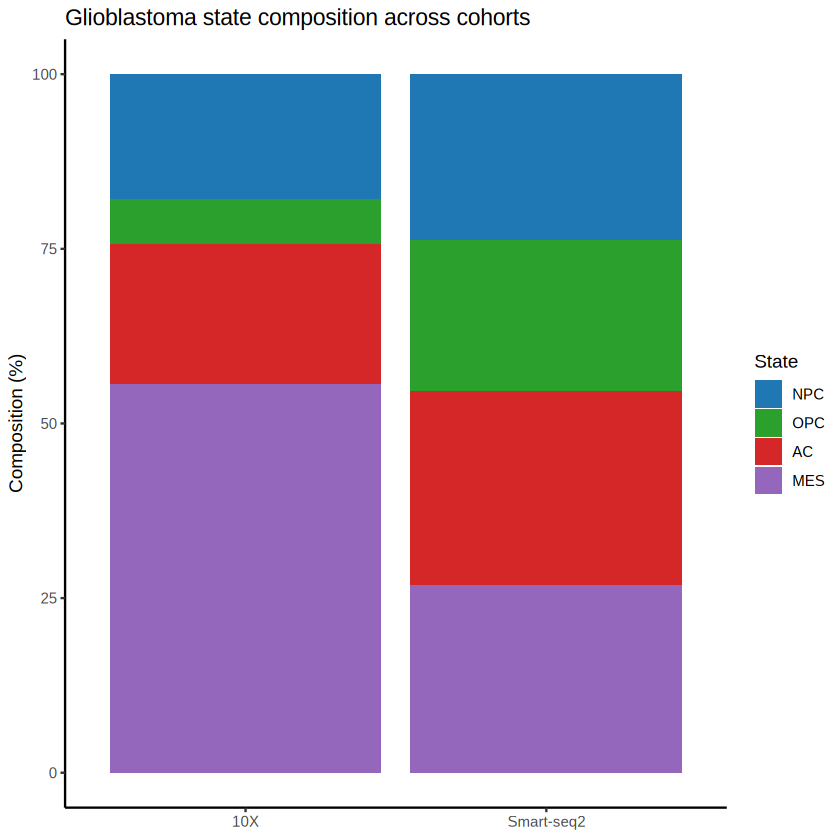

In [16]:
# Stacked bar chart of state proportions per patient
all_states <- bind_rows(
    data.frame(cohort = 'Smart-seq2', patient = ss2$patient,  state = ss2$state),
    data.frame(cohort = '10X',         patient = tenx$patient, state = tenx$state)
)

# Per-cohort summary
cohort_summary <- all_states %>%
    group_by(cohort, state) %>%
    summarise(n = n(), .groups = 'drop') %>%
    group_by(cohort) %>%
    mutate(pct = 100 * n / sum(n))

cat('State composition by cohort:\n')
print(cohort_summary)

# Plot — compare overall composition between cohorts
p_comp <- ggplot(cohort_summary, aes(x = cohort, y = pct, fill = state)) +
    geom_bar(stat = 'identity', position = 'stack') +
    scale_fill_manual(values = state_colors) +
    labs(title = 'Glioblastoma state composition across cohorts',
         x = NULL, y = 'Composition (%)', fill = 'State') +
    theme_classic(base_size = 11)
save_fig(p_comp, '05_state_composition_cohorts', w = 6, h = 5)
print(p_comp)

  saved ../figures/06_state_composition_per_patient.png 


  saved ../figures/06_state_composition_per_patient.tiff 


  saved ../figures/06_state_composition_per_patient.pdf 


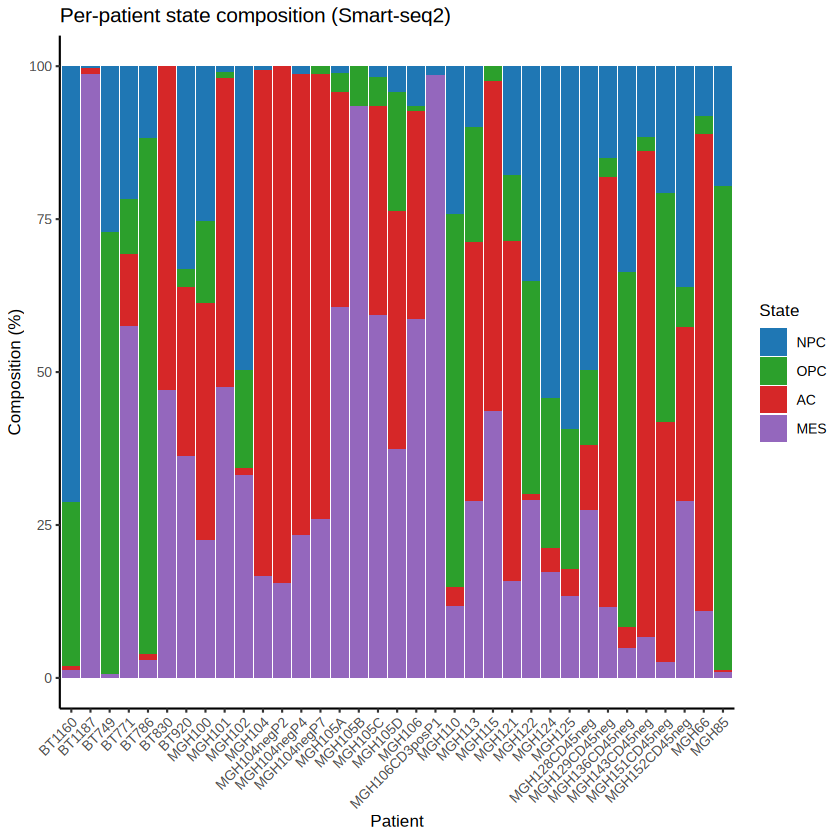

In [17]:
# Per-patient state composition (Smart-seq2 only, sufficient cells per patient)
patient_summary <- all_states %>%
    filter(cohort == 'Smart-seq2') %>%
    group_by(patient, state) %>%
    summarise(n = n(), .groups = 'drop') %>%
    group_by(patient) %>%
    mutate(pct = 100 * n / sum(n))

p_patient <- ggplot(patient_summary, aes(x = patient, y = pct, fill = state)) +
    geom_bar(stat = 'identity', position = 'stack') +
    scale_fill_manual(values = state_colors) +
    labs(title = 'Per-patient state composition (Smart-seq2)',
         x = 'Patient', y = 'Composition (%)', fill = 'State') +
    theme_classic(base_size = 10) +
    theme(axis.text.x = element_text(angle = 45, hjust = 1))
save_fig(p_patient, '06_state_composition_per_patient', w = 10, h = 5)
print(p_patient)

## 10. Export

In [18]:
saveRDS(ss2,  file.path(RESULTS_DIR, 'neftel_ss2_processed.rds'))
saveRDS(tenx, file.path(RESULTS_DIR, 'neftel_10x_processed.rds'))

# Save state scores and assignments as CSV for downstream re-use
scores_df <- bind_rows(
    data.frame(
        cohort = 'Smart-seq2', patient = ss2$patient,
        cell = colnames(ss2),
        MES = ss2$MES_score, AC = ss2$AC_score,
        OPC = ss2$OPC_score, NPC = ss2$NPC_score,
        state = as.character(ss2$state), bp_x = ss2$bp_x, bp_y = ss2$bp_y
    ),
    data.frame(
        cohort = '10X', patient = tenx$patient,
        cell = colnames(tenx),
        MES = tenx$MES_score, AC = tenx$AC_score,
        OPC = tenx$OPC_score, NPC = tenx$NPC_score,
        state = as.character(tenx$state), bp_x = tenx$bp_x, bp_y = tenx$bp_y
    )
)
write.csv(scores_df, file.path(RESULTS_DIR, 'state_scores_all_cells.csv'), row.names = FALSE)

cat('Outputs saved:\n')
cat('  - neftel_ss2_processed.rds (', round(file.size(file.path(RESULTS_DIR, 'neftel_ss2_processed.rds'))/1e6, 1), 'MB)\n')
cat('  - neftel_10x_processed.rds (', round(file.size(file.path(RESULTS_DIR, 'neftel_10x_processed.rds'))/1e6, 1), 'MB)\n')
cat('  - state_scores_all_cells.csv (', nrow(scores_df), 'rows )\n')

cat('\nFinal summary:\n')
cat('Smart-seq2:', ncol(ss2), 'cells,', length(unique(ss2$patient)), 'patients\n')
cat('10X:       ', ncol(tenx), 'cells,', length(unique(tenx$patient)), 'patients\n')

Outputs saved:


  - neftel_ss2_processed.rds ( 724.1 MB)


  - neftel_10x_processed.rds ( 233.2 MB)


  - state_scores_all_cells.csv ( 21432 rows )



Final summary:


Smart-seq2: 7914 cells, 35 patients


10X:        13518 cells, 10 patients
